# Chapter 1: The Reliability Gap

Companion notebook for *Building Reliable AI-Assisted Software Systems* (Packt)

**Author: Imran Ahmad**

AI-assisted software has crossed the line from demo to dependency, and every
team that ships it discovers the same uncomfortable truth: the qualities
that make these systems impressive in a prototype are the qualities that
make them unreliable in production. Chapter 1 names that distance the
**Reliability Gap**: the measurable gap between demonstration performance
and production reliability. It is structural, and no model release will
close it for you.

The chapter argues from architecture rather than code, with one deliberate
exception, and this notebook is built around it: Listing 1.1, five
identical calls that rarely produce one identical answer. Around that
single program, the notebook makes the chapter's other quantitative claims
runnable: the compounding arithmetic of chained steps, the 80/20 Demo Trap
as a simulation you can rerun, and the agent loop whose action sequences
drift run to run.

## Objectives

By the end of this notebook you will be able to:

* Demonstrate, in a dozen lines, why identical inputs stop producing
  identical outputs the moment a sampled distribution replaces a computed
  value, and why exact-match assertions fail against working behavior.
* Compute how per-step reliability compounds across a chain, and why a
  system of impressive parts can still be an unreliable whole.
* Reproduce the 80/20 Demo Trap: the same prototype scoring near-perfect
  on demo traffic and roughly four-in-five on production traffic, because
  the demo samples only the friendliest slice of the input distribution.
* Watch a model-in-a-loop turn output variance into behavior variance:
  the same task, ten runs, and a spread of distinct action trajectories.
* State the chapter's thesis in one sentence: you cannot make the model
  deterministic, so you build a deterministic shell around a probabilistic
  core.

## How to run this notebook

**Simulation Mode works with zero keys and zero setup.** Every cell runs
offline against a seeded mock model, so two consecutive runs are
byte-identical, and the first code cell prints a green banner to confirm
the mode. If you add an `OPENAI_API_KEY` to a `.env` file, Listing 1.1
will call a real model instead (and fall back to the mock on any failure);
the printed chapter runs the listing live, and the mock reproduces the
same fan-out without an account.

## Setup *(Act 0)*

In [1]:
import math
import random
from collections import Counter

import matplotlib.pyplot as plt

from resilience import detect_mode, log_info
from model_sim import (
    CANON_CH1, mock_complete, live_complete_or_mock, run_traffic, run_agent,
)

random.seed(42)
MODE = detect_mode()
log_info("Chapter 1 argues from architecture; this notebook runs its numbers.")

SIMULATION MODE - no API key detected, running fully offline. Every response comes from the committed snapshot and the deterministic mock layer, and every number in this notebook is reproducible without a key.
[INFO] Chapter 1 argues from architecture; this notebook runs its numbers.


## Act I · Five identical calls *(section: what changes when the core is probabilistic · Listing 1.1)*

A model does not return a computed value. It returns a sample drawn from
a distribution. Executing the same input in a traditional loop yields
identical outputs; passing the same prompt to a model five times yields
five semantically similar but lexically distinct responses.
Exact-match assertions stop working entirely, and nothing in the syntax
warns you that anything has changed.

You don't have to take this on faith; you can watch it happen. Listing 1.1
below is the chapter's one program, reproduced as printed: it calls the
same model with the same prompt five times and collects the answers into a
set. Against a deterministic function this loop would be pointless, since
five identical calls collapse to a single entry. Against a probabilistic
core, the set grows. (In Simulation Mode the `complete` call is the seeded
mock; with a key in `.env` it is a real model.)

In [2]:
# Listing 1.1 - five identical calls, and rarely one identical answer
prompt = "In one short sentence, what is the refund window?"

# Call the same model, with the same prompt, five times.
answers = []
for run in range(CANON_CH1["CALLS"]):
    answers.append(live_complete_or_mock(prompt, run).strip())

# A deterministic function would return one unique answer. How many do we get?
unique = set(answers)
print(f"{len(unique)} distinct answers from {CANON_CH1['CALLS']} identical calls")
for text in sorted(unique):
    print("-", text)

4 distinct answers from 5 identical calls
- Our refund window is 30 days from the purchase date.
- Purchases can be refunded up to 30 days after you buy.
- You can get a refund within 30 days.
- You have a 30-day window to request a refund.


Run this against a traditional function and the count is always one, by
definition. Against a model it is routinely three, four, or five. No
variant is a crash; the wording shifts on every call; and a unit test
asserting equality against a single golden string would pass or fail
essentially at random depending on which sample it happened to draw. The
variation is the system working exactly as designed, which is precisely
what makes it dangerous: random garbage is easy to detect, but confident,
fluent, plausible text that contains a factual error passes superficial
checks with ease. Chapter 3 replaces the golden string with a golden
rubric; this cell is the reason it has to.

## Act II · The compounding gap *(section: the arithmetic of chained steps)*

A single call at ninety percent reliability sounds close to done. Chain
five such steps, each depending on the last, and the arithmetic does
something teams consistently underestimate. The cell below computes the
chapter's example and then sweeps the same curve for better components,
because the shape of the curve is the argument: reliability compounds
against you, and the impressive per-step number is not the number your
user experiences.

one step at 90% -> a 5-step chain at 59.0%
(the chapter's figure: 0.9 ** 5 = 0.5905)


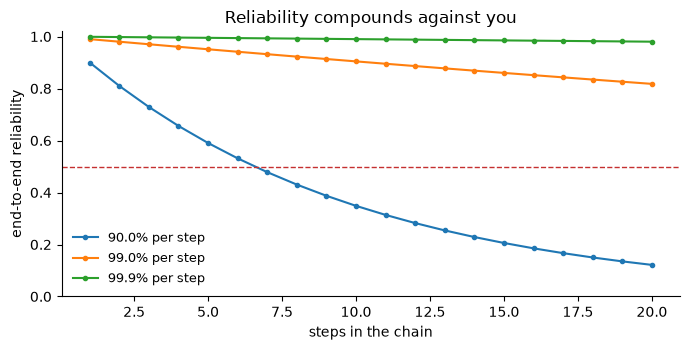

An 80% system fails one request in five. The distance from there to
production-grade is not one more sprint; it is the subject of this book.


In [3]:
p = CANON_CH1["STEP_RELIABILITY"]
n = CANON_CH1["CHAIN_STEPS"]
print(f"one step at {p:.0%} -> a {n}-step chain at {p ** n:.1%}")
print(f"(the chapter's figure: {p} ** {n} = {p ** n:.4f})")

steps = range(1, 21)
fig, ax = plt.subplots(figsize=(7, 3.6))
for step_p in (0.90, 0.99, 0.999):
    ax.plot(steps, [step_p ** s for s in steps], marker="o", ms=3,
            label=f"{step_p:.1%} per step")
ax.axhline(0.5, color="#C53030", lw=1, ls="--")
ax.set_xlabel("steps in the chain"); ax.set_ylabel("end-to-end reliability")
ax.set_title("Reliability compounds against you")
ax.set_ylim(0, 1.02); ax.legend(frameon=False, fontsize=9)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout(); plt.show()

print("An 80% system fails one request in five. The distance from there to")
print("production-grade is not one more sprint; it is the subject of this book.")

## Act III · The 80/20 Demo Trap *(section: why the demo lies honestly)*

The chapter names the pattern the **80/20 Demo Trap**: a superficial
success rate that looks impressive in controlled environments but
collapses under production-scale, adversarial traffic. It is explicitly an
illustrative pattern rather than a measured law, and this simulation keeps
it that way: one prototype with fixed per-slice success rates, faced with
two different input distributions. The demo samples only the friendliest
slice. Production samples everything users actually send.

In [4]:
demo_pass, demo_slices = run_traffic("demo", CANON_CH1["DEMO_QUESTIONS"])
prod_pass, prod_slices = run_traffic("production", CANON_CH1["PROD_TICKETS"])

print(f"the demo:      {demo_pass}/{CANON_CH1['DEMO_QUESTIONS']} "
      f"({demo_pass / CANON_CH1['DEMO_QUESTIONS']:.0%})  <- the room applauds")
print(f"production:    {prod_pass}/{CANON_CH1['PROD_TICKETS']} "
      f"({prod_pass / CANON_CH1['PROD_TICKETS']:.1%})")
print()
print("the same system, sliced by what production actually sent:")
for s, (ok, total) in prod_slices.items():
    print(f"  {s:26s} {ok:3d}/{total:3d}  ({ok / total:.0%})")

the demo:      12/12 (100%)  <- the room applauds
production:    413/500 (82.6%)

the same system, sliced by what production actually sent:
  clean, common questions    280/294  (95%)
  ambiguous phrasing          75/ 96  (78%)
  multi-part tickets          32/ 51  (63%)
  edge-case policies          20/ 37  (54%)
  adversarial or hostile       6/ 22  (27%)


The demo was not false; it was a biased sample, drawn from the slice where
the prototype genuinely is strong. Production is the corrected sample.
Notice that nothing about the system changed between the two numbers; only
the input distribution did, which is why no amount of watching the demo
again would have predicted the production rate, and why Chapter 3 builds
the corrected sample deliberately (a golden dataset mined from real
traffic) instead of waiting for production to run the experiment for you.

## Act IV · A model in a loop *(section: agents compound the variance)*

An agent is a model placed inside a loop, and the loop compounds the
variance: sampling varies the next action, the growing context varies the
next prompt, and external tools vary the state the next step sees. The
cell below runs the same fixed task ten times through a toy agent loop and
counts the distinct action trajectories. With a deterministic planner the
count would be one.

In [5]:
runs = [run_agent(r, steps=CANON_CH1["AGENT_STEPS"])
        for r in range(CANON_CH1["AGENT_RUNS"])]
distinct = Counter(tuple(r) for r in runs)
print(f"{len(distinct)} distinct trajectories in {len(runs)} runs of the same task:")
for i, (seq, count) in enumerate(distinct.most_common(), 1):
    print(f"  x{count}  {' -> '.join(seq)}")

10 distinct trajectories in 10 runs of the same task:
  x1  read_ticket -> search_kb -> ask_clarifying -> draft_reply -> read_ticket -> ask_clarifying
  x1  read_ticket -> check_policy -> read_ticket -> escalate
  x1  read_ticket -> ask_clarifying -> search_kb -> check_policy -> search_kb -> read_ticket
  x1  read_ticket -> draft_reply -> search_kb -> check_policy -> read_ticket -> escalate
  x1  read_ticket -> search_kb -> draft_reply -> check_policy -> draft_reply -> escalate
  x1  read_ticket -> ask_clarifying -> read_ticket -> search_kb -> read_ticket -> search_kb
  x1  read_ticket -> escalate
  x1  read_ticket -> draft_reply -> ask_clarifying -> read_ticket -> check_policy -> search_kb
  x1  read_ticket -> search_kb -> draft_reply -> search_kb -> draft_reply -> ask_clarifying
  x1  read_ticket -> ask_clarifying -> search_kb -> read_ticket -> search_kb -> draft_reply


Every trajectory is individually defensible, which is exactly the problem:
a system whose control flow is sampled cannot be debugged by rerunning it,
cannot be certified by watching one good run, and cannot be bounded by
hoping. The output-level variance of Act I has become behavior-level
variance, and cost, latency, and risk now vary with it. Parts IV and V of
the book put the loop back under deterministic control; Chapter 2 begins
by naming the architecture that does it.

## Act V · The poet and the accountant *(section: the thesis)*

The chapter closes on its central image. The model is the poet: fluent,
capable, and constitutionally incapable of balancing the books. You do not
fix the poet, and you do not fire the poet. You give the poet an
accountant: a surrounding layer of deterministic engineering that supplies
the reproducibility, verification, and auditability the core cannot
provide for itself. The book calls that layer the **deterministic shell**,
and everything this notebook demonstrated is a reason one of its rings
exists.

In [6]:
observations = [
    ("five calls fan out into distinct answers", "evals grade meaning, not strings", "Part II"),
    ("what the model reads decides what it says", "context is assembled, budgeted, tested", "Part III"),
    ("a loop compounds variance into behavior", "code owns the loop; the model fills steps", "Part IV"),
    ("one bad output can be an unauthorized promise", "validation on both sides of the model", "Part V"),
]
print("what this notebook showed        -> the ring that answers it")
for seen, ring, part in observations:
    print(f"  {seen:44s} {ring}  ({part})")

what this notebook showed        -> the ring that answers it
  five calls fan out into distinct answers     evals grade meaning, not strings  (Part II)
  what the model reads decides what it says    context is assembled, budgeted, tested  (Part III)
  a loop compounds variance into behavior      code owns the loop; the model fills steps  (Part IV)
  one bad output can be an unauthorized promise validation on both sides of the model  (Part V)


## Summary

One mechanical difference drives the whole chapter: a model returns a
sample, not a computed value. From that follow the broken assertions of
Act I, the compounding arithmetic of Act II, the honest lie of the demo in
Act III, and the drifting trajectories of Act IV. None of these are bugs,
and that is the point of the chapter's title: the gap between the demo and
production is structural, so it has to be engineered across rather than
prompted away.

Hold on to three things. The variation is the capability; you cannot
remove it without removing the reason the system is useful. The demo is a
biased sample, and only a deliberately curated one corrects it. And the
gap is closed by ordinary software engineering arranged around the model,
not by a better model alone.

### Exercises

1. **Reflection.** Run Act I's loop with your own prompt (or your own
   product's model, in Live Mode). How many distinct answers do five calls
   produce, and would any pair of them behave differently in front of a
   customer?

2. **Application.** In Act III's simulation, edit the traffic profile in
   `model_sim.py` to match your own product's slices as honestly as you
   can, and rerun. What does your demo rate predict, and what does your
   production rate predict?

3. **Discussion.** Take one AI feature you know well and list where each
   of the four rings (evals, context, control flow, validation) currently
   lives, if anywhere. Which observation from this notebook does the
   missing ring leave unanswered?

### The hand-off

The poet stays; the accountant arrives. Chapter 2 names the architecture
(the deterministic shell around a probabilistic core), builds the same
support feature with and without it, and introduces the Four Pillars the
rest of the book constructs. Its companion bundle sits alongside this one
in the repository.